# Agent Orchestration: Multi-Agent Supervisor

In the previous notebook, we used a fixed sequential chain. But what if the task is unpredictable? Enter the **Supervisor Pattern** (also known as the Manager pattern).

## 1. What is a Supervisor?
A **Supervisor** is a central agent that:
1. Receives the user's request.
2. Decides which specialized "Worker" agent is best suited for the task.
3. Delegates the task to that worker.
4. Receives the result back and decides whether to ask another worker or finish.

---

## 2. Environment Setup
We need multiple workers. Let's create a **Researcher** and a **Coder**.

In [8]:
import os
from typing import Annotated, TypedDict, List, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("Supervisor Environment Ready!")

Supervisor Environment Ready!


## 3. Defining the Supervisor's Decision Model
We use **Structured Output** to ensure the supervisor always gives us a valid command (which worker to call next).

In [2]:
class Router(BaseModel):
    """Decide which worker should act next."""
    next_worker: Literal["Researcher", "Coder", "FINISH"] = Field(
        ...,
        description="The next worker to act. If the task is done, choose FINISH."
    )

supervisor_llm = llm.with_structured_output(Router)

## 4. Defining the Team State
The supervisor and workers all share the same conversation history.

In [3]:
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]
    # We add next_worker to the state so the graph can route correctly
    next_worker: str

## 5. Defining the Workers
Each worker is a specialized prompt.

In [4]:
def researcher_node(state: AgentState):
    system_msg = SystemMessage(content="You are a researcher. Provide facts about the user's topic.")
    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [AIMessage(content=response.content, name="Researcher")]}

def coder_node(state: AgentState):
    system_msg = SystemMessage(content="You are a Python programmer. Write code based on the user's request.")
    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [AIMessage(content=response.content, name="Coder")]}

## 6. Defining the Supervisor Node
The supervisor looks at the history and picks the next worker.

In [5]:
def supervisor_node(state: AgentState):
    system_msg = SystemMessage(content="""You are the Manager. 
    If the user wants facts, call Researcher.
    If the user wants code, call Coder.
    If the task is completed, choose FINISH.""")
    response = supervisor_llm.invoke([system_msg] + state["messages"])
    # Return a dictionary to update the AgentState
    return {"next_worker": response.next_worker}

## 7. Building & Visualizing the Orchestration Graph
This graph is **Dynamic**. The Supervisor decides the flow.

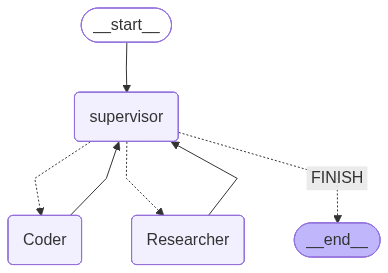

In [6]:
workflow = StateGraph(AgentState)

workflow.add_node("Researcher", researcher_node)
workflow.add_node("Coder", coder_node)
workflow.add_node("supervisor", supervisor_node)

# Start with the supervisor
workflow.add_edge(START, "supervisor")

# Workers always report back to the supervisor
workflow.add_edge("Researcher", "supervisor")
workflow.add_edge("Coder", "supervisor")

# Dynamic routing based on supervisor's output in the state
workflow.add_conditional_edges(
    "supervisor",
    lambda x: x["next_worker"], 
    {
        "Researcher": "Researcher",
        "Coder": "Coder",
        "FINISH": END
    }
)

app = workflow.compile()

# Visualize
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed.")

## 8. Running the Team
Let's try a coding request and see if the Supervisor correctly routes it to the Coder.

In [7]:
query = "Write a python script to calculate the Fibonacci sequence."
for chunk in app.stream({"messages": [HumanMessage(content=query)]}):
    if "supervisor" in chunk:
        # chunk['supervisor'] contains the dictionary returned by the node
        print(f"Supervisor chose: {chunk['supervisor']['next_worker']}")
    else:
        worker_name = list(chunk.keys())[0]
        print(f"\n--- {worker_name} is working... ---")
        print(chunk[worker_name]["messages"][0].content)

Supervisor chose: Coder

--- Coder is working... ---
This Python script calculates the Fibonacci sequence using two common and efficient methods: an **iterative approach** and a **recursive approach with memoization (dynamic programming)**. It also includes user input for the number of terms and basic error handling.

```python
import sys

def fibonacci_iterative(n):
    """
    Calculates the Fibonacci sequence up to the nth number using an iterative approach.

    This method is generally preferred for its efficiency (O(n) time complexity
    and O(n) space complexity for storing the sequence, or O(1) if only the
    last number is needed).

    Args:
        n (int): The number of Fibonacci terms to generate.

    Returns:
        list: A list containing the first n Fibonacci numbers.
              Returns an empty list if n <= 0.
    """
    if n <= 0:
        return []
    elif n == 1:
        return [0]
    else:
        sequence = [0, 1]
        a, b = 0, 1
        # We already 

## 9. Summary & Pro-Tips
1. **Centralized Logic**: The Supervisor pattern centralizes the "Decision Making," making it easier to debug why an agent did (or didn't) get assigned.
2. **State Management**: Always remember that LangGraph passes the entire **State Dictionary** to routing functions. Use `x['key']` for robust access.
3. **Scalability**: You can add 5 more workers (e.g., Designer, Tester, Deployer) by just adding nodes and updating the `Router` Literal.

---